In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Setting style
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# Load data
df = pd.read_csv('../data/cleaned/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"✅ Data loaded: {df.shape}")
df.head()

✅ Data loaded: (779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice,Year,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,Tuesday


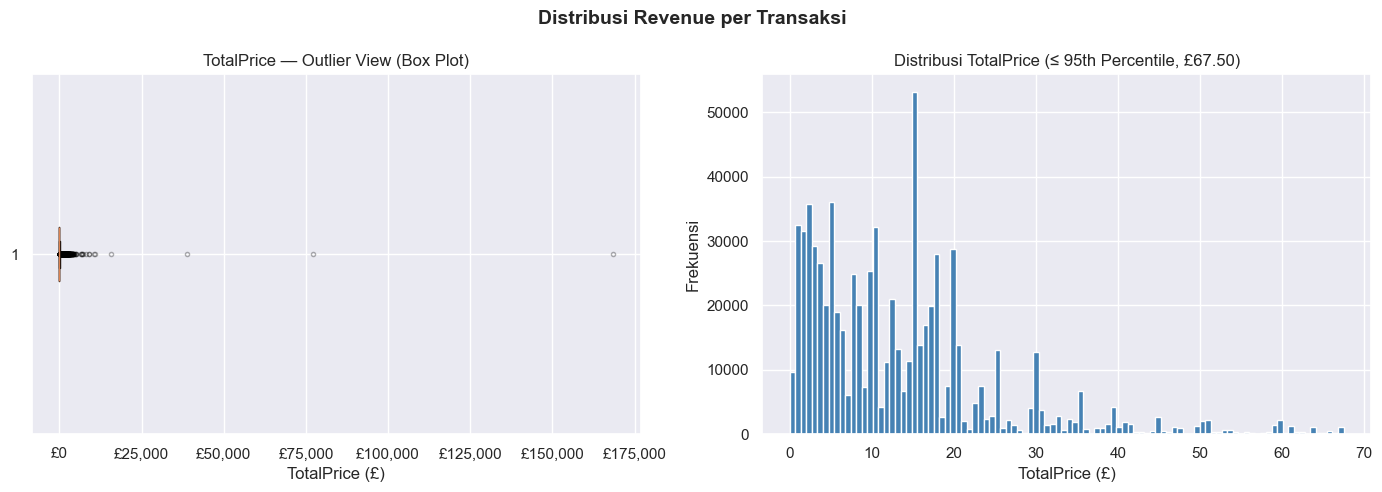

In [ ]:
# Distribusi revenue per transaksi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: Box plot untuk tunjukkan outlier
axes[0].boxplot(df['TotalPrice'], vert=False, flierprops=dict(marker='.', alpha=0.3))
axes[0].set_title('TotalPrice — Outlier View (Box Plot)')
axes[0].set_xlabel('TotalPrice (£)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Kanan: Histogram 95th percentile tetap sama
p95 = df['TotalPrice'].quantile(0.95)
df_filtered = df[df['TotalPrice'] <= p95]
axes[1].hist(df_filtered['TotalPrice'], bins=100, color='steelblue', edgecolor='white')
axes[1].set_title(f'Distribusi TotalPrice (≤ 95th Percentile, £{p95:.2f})')
axes[1].set_xlabel('TotalPrice (£)')
axes[1].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Revenue per Transaksi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/01_revenue_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

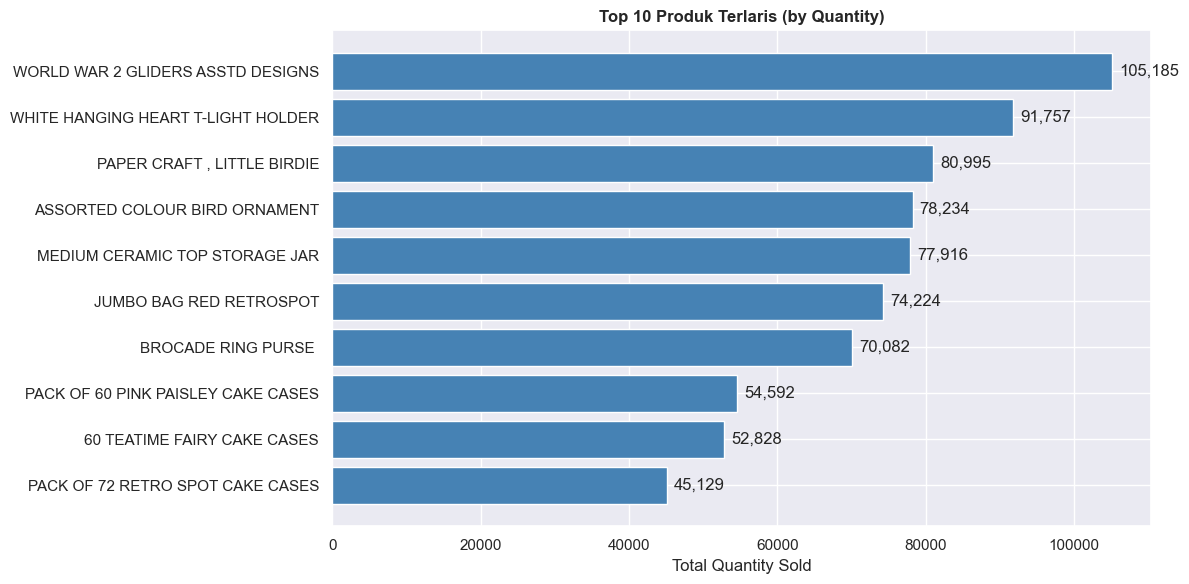

In [ ]:
# Top 10 produk terlaris

top_products = (df.groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_products['Description'], top_products['Quantity'], color='steelblue')
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.set_title('Top 10 Produk Terlaris (by Quantity)', fontweight='bold')
ax.set_xlabel('Total Quantity Sold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/02_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

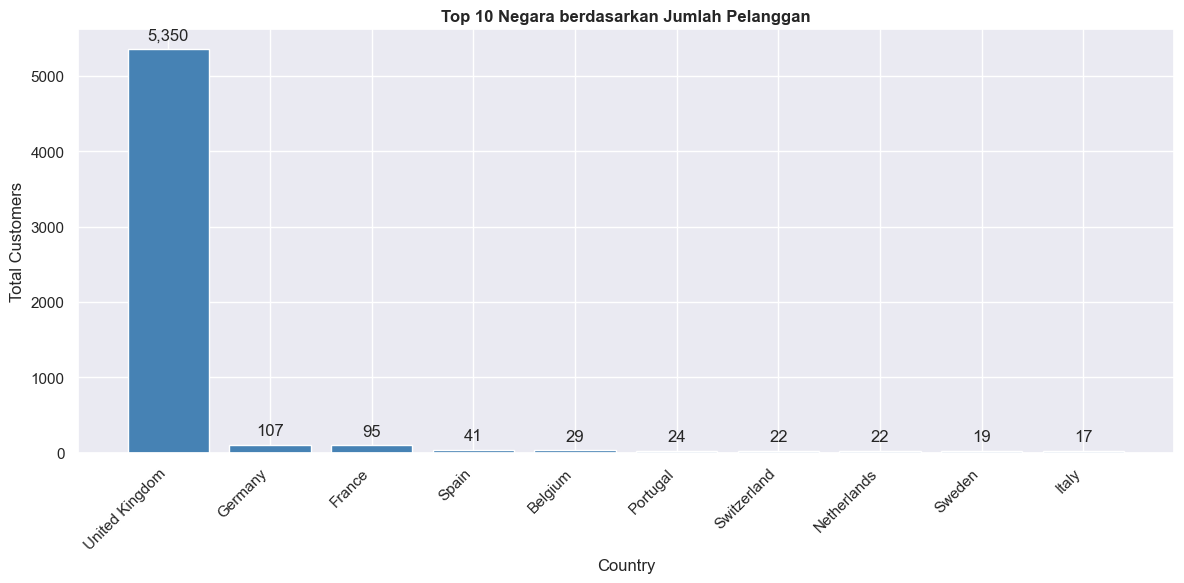

In [ ]:
# Distribusi pelanggan per negara

top_countries = (df.groupby('Country')['Customer ID']
                 .nunique()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())
top_countries.columns = ['Country', 'Total_Customers']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top_countries['Country'], top_countries['Total_Customers'], color='steelblue')
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.set_title('Top 10 Negara berdasarkan Jumlah Pelanggan', fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Total Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/03_customers_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

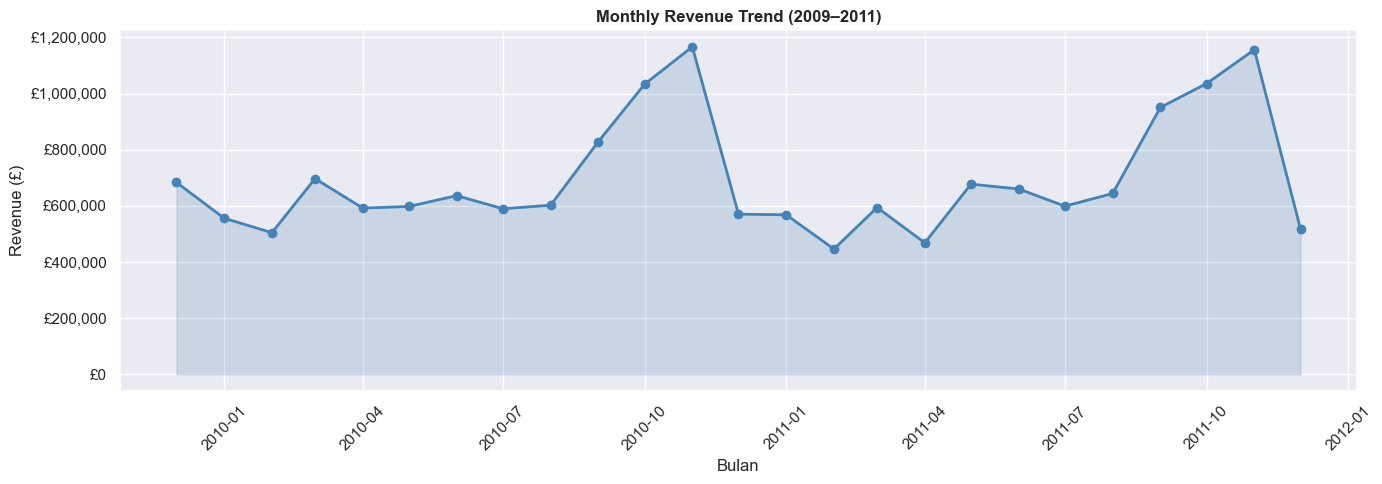

In [ ]:
# Trend revenue per bulan

monthly = (df.groupby(['Year', 'Month'])['TotalPrice']
           .sum()
           .reset_index())
monthly['YearMonth'] = pd.to_datetime(monthly[['Year', 'Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['YearMonth'], monthly['TotalPrice'], 
        marker='o', color='steelblue', linewidth=2)
ax.fill_between(monthly['YearMonth'], monthly['TotalPrice'], alpha=0.2, color='steelblue')
ax.set_title('Monthly Revenue Trend (2009–2011)', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/04_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

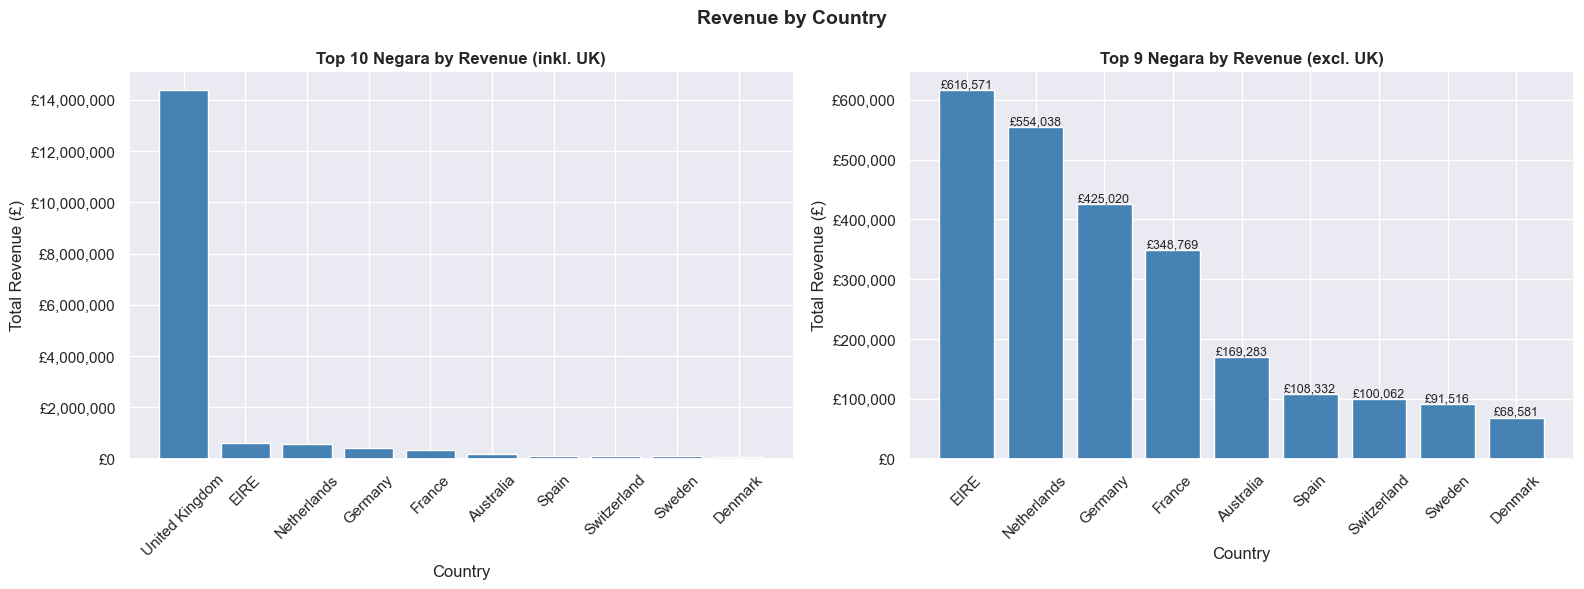

In [12]:
# Top 10 negara berdasarkan revenue

top_revenue_country = (df.groupby('Country')['TotalPrice']
                       .sum()
                       .sort_values(ascending=False)
                       .head(10)
                       .reset_index())
top_revenue_country.columns = ['Country', 'Total_Revenue']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kiri: Semua top 10 termasuk UK
axes[0].bar(top_revenue_country['Country'], 
            top_revenue_country['Total_Revenue'], color='steelblue')
axes[0].set_title('Top 10 Negara by Revenue (inkl. UK)', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Total Revenue (£)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Kanan: Exclude UK untuk melihat negara lain lebih jelas
top_ex_uk = top_revenue_country[top_revenue_country['Country'] != 'United Kingdom']
axes[1].bar(top_ex_uk['Country'], top_ex_uk['Total_Revenue'], color='steelblue')
axes[1].set_title('Top 9 Negara by Revenue (excl. UK)', fontweight='bold')
axes[1].set_xlabel('Country')
axes[1].set_ylabel('Total Revenue (£)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar in axes[1].patches:
    axes[1].annotate(f'£{bar.get_height():,.0f}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Revenue by Country', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/05_revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

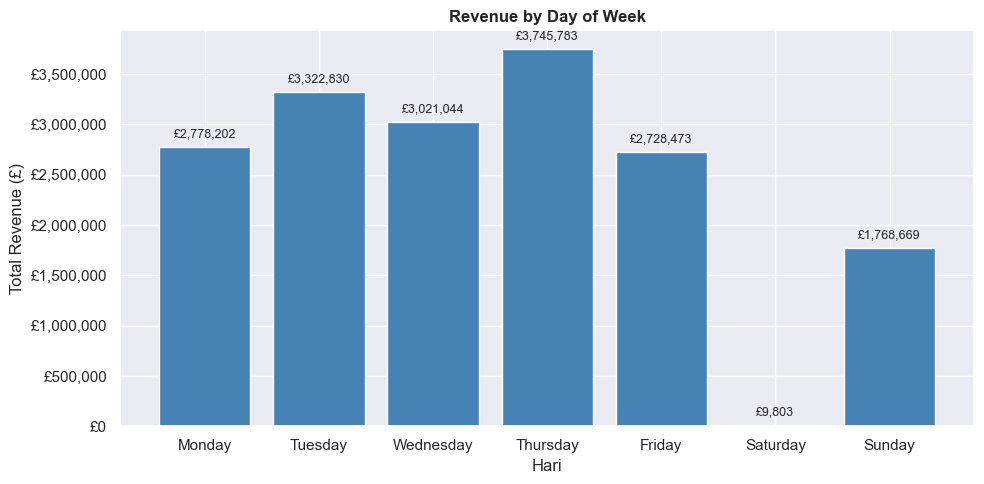

In [ ]:
# Pola revenue per hari dalam seminggu

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = (df.groupby('DayOfWeek')['TotalPrice']
               .sum()
               .reindex(dow_order)
               .reset_index())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_revenue['DayOfWeek'], dow_revenue['TotalPrice'], color='steelblue')
ax.bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=9)
ax.set_title('Revenue by Day of Week', fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/06_revenue_by_dow.png', dpi=150, bbox_inches='tight')
plt.show()

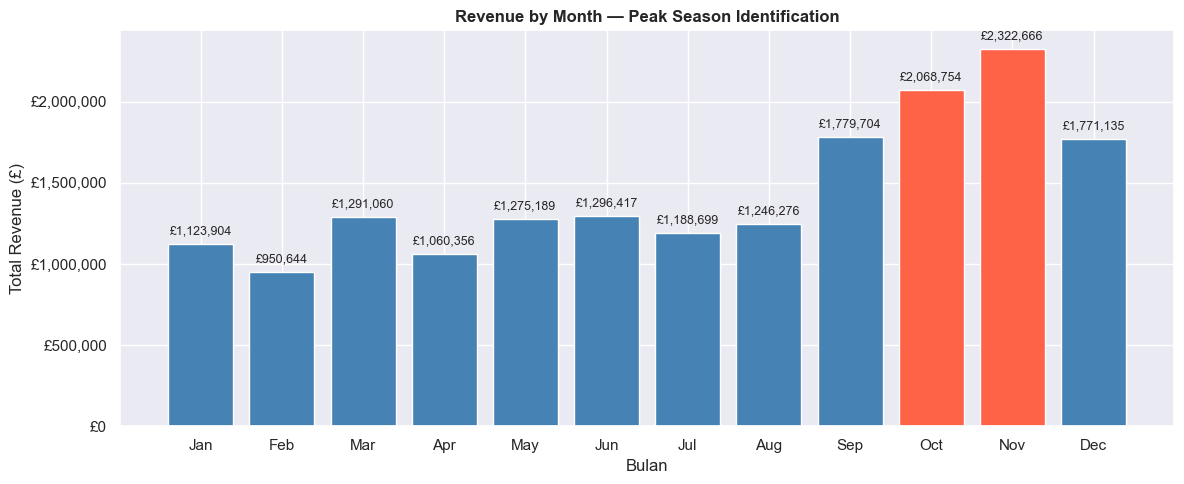

Top 2 peak months: ['Nov', 'Oct']


In [11]:
# Revenue per bulan dan puncaknya

monthly_avg = (df.groupby('Month')['TotalPrice']
               .sum()
               .reset_index())
monthly_avg.columns = ['Month', 'Total_Revenue']
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_avg['Month_Name'] = monthly_avg['Month'].map(month_names)

# Otomatis deteksi 2 bulan dengan revenue tertinggi
top2_months = monthly_avg.nlargest(2, 'Total_Revenue')['Month'].values
colors = ['tomato' if x in top2_months else 'steelblue' for x in monthly_avg['Month']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(monthly_avg['Month_Name'], monthly_avg['Total_Revenue'], color=colors)
ax.bar_label(bars, fmt='£{:,.0f}', padding=5, fontsize=9)
ax.set_title('Revenue by Month — Peak Season Identification', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Total Revenue (£)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.savefig('../reports/07_peak_season.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Top 2 peak months: {[month_names[m] for m in top2_months]}")

In [ ]:
# Simpan top products untuk dipakai di analisis selanjutnya
top_products = (df.groupby('Description')['Quantity']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .reset_index())
top_products.to_csv('../data/cleaned/top_products.csv', index=False)

# Simpan revenue by country
revenue_country = (df.groupby('Country')['TotalPrice']
                   .sum()
                   .sort_values(ascending=False)
                   .reset_index())
revenue_country.columns = ['Country', 'Total_Revenue']
revenue_country.to_csv('../data/cleaned/revenue_by_country.csv', index=False)

print("top_products.csv berhasil disimpan.")
print("revenue_by_country.csv berhasil disimpan.")

top_products.csv berhasil disimpan!
revenue_by_country.csv berhasil disimpan!

Phase 5 — EDA Selesai!
